## dMdpsi <-> M(psi) consistency check
Checking the process of going back and forth between dmdpsi and M(psi) to see whether information is lost (or not).

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson

In [2]:
# first define functions for reference use
B_star = 1e8
R_star = 1e4
psi_star = B_star*R_star**2/2
bratio = 10
cs = 1e6
G = 6.67e-11
M_sol = 1.989e30
M_star = 1.4*M_sol
x0 = (cs*R_star)**2/G/M_star
ma = 5e-7*M_sol
psi_0 = np.sqrt(cs**2*ma/x0**3)
n_contours = 127
dmu = 1/n_contours
mu_levels = np.empty(n_contours)
    
for i in range(n_contours):
    contour_mesh_value = (n_contours - i)/(n_contours+1.)/dmu
    mu_levels[i] = contour_mesh_value*dmu
    
psi_levels = (psi_star/psi_0)*(1-mu_levels*mu_levels)
psi_levels = np.append(np.append(0,psi_levels),psi_star/psi_0)
m_psi_ref = 0.5*(1 - np.exp(-psi_levels*psi_0/psi_star*bratio)) / (1 - np.exp(-bratio))
dmdpsi_ref = 0.5*bratio*psi_0/psi_star*np.exp(-psi_levels*psi_0/psi_star*bratio) / (1 - np.exp(-bratio))

psi_levels_highres = np.linspace(psi_levels[0],psi_levels[-1],400)
dmdpsi_ref_highres = 0.5*bratio*psi_0/psi_star*np.exp(-psi_levels_highres*psi_0/psi_star*bratio) / (1 - np.exp(-bratio))

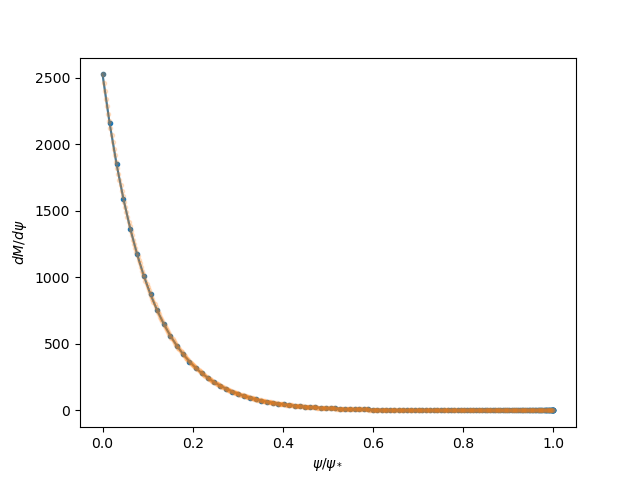

In [3]:
%matplotlib widget
fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,dmdpsi_ref,'.-')
ax.plot(psi_levels_highres*psi_0/psi_star,dmdpsi_ref_highres,'.-',alpha = 0.2)
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$dM/d\psi$")
plt.show()

Now confirm that integrating dmdpsi yields M_psi_ref:

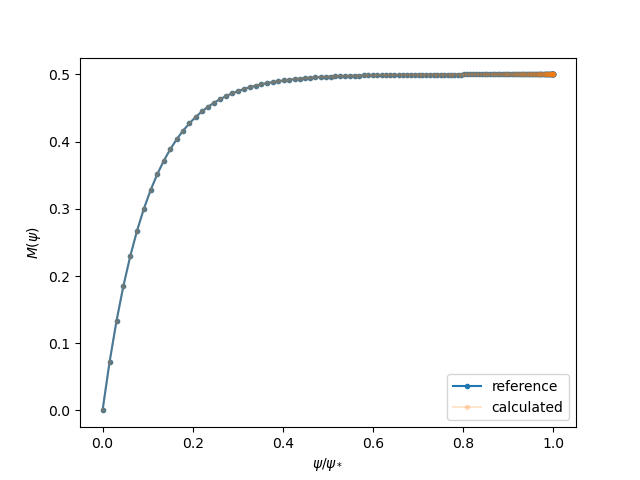

In [4]:
m_psi_calc = np.array([simpson(dmdpsi_ref[:i+1],psi_levels[:i+1]) for i in range(len(dmdpsi_ref))])

fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,m_psi_ref,'.-',label="reference")
ax.plot(psi_levels*psi_0/psi_star,m_psi_calc,'.-',label="calculated",alpha = 0.2)
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$M(\psi)$")
plt.show()

The aim is to do *something* to $dM/d\psi$ such that the fluxtube masses are equalised. The task to is figure out what that *something* is. First show the fluxtube mass:

In [5]:
fluxtube_mass = m_psi_calc[1:] - m_psi_calc[:-1]
fluxtube_mass = np.append(fluxtube_mass,0)

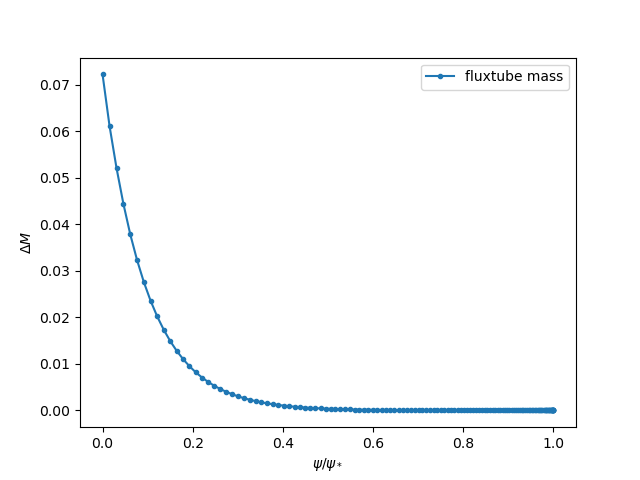

In [6]:
fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass,'.-',label="fluxtube mass")
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$\Delta M$")
plt.show()


Question: can we go from this plot to dmdpsi in a consistent, accurate way? How do we do it? 

Actually, that's not the problem. We can add arbitrary masses to the dmdpsi curve no problem - the issue occurs afterwards, when we have the modified dmdpsi curve, and we want to use it to see what the mass is by recalculating `fluxtube_mass`. So let's modify dmdpsi and see what it looks like first. To do this, we calculate the amount of mass that must be moved to equalise fluxtube masses in the i-th fluxtube. Pick one randomly, say....14th:

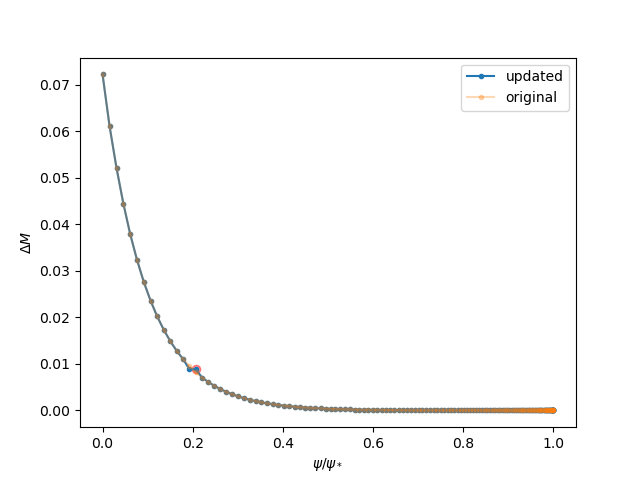

In [7]:
index = 14
# want to equalise the masses in the fluxtubes to the left and right of the 34th flux surface
delta_m = 0.5*(fluxtube_mass[index-1] - fluxtube_mass[index])
fluxtube_mass_updated = np.copy(fluxtube_mass)
fluxtube_mass_updated[index - 1] -= delta_m
fluxtube_mass_updated[index] += delta_m

fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass_updated,'.-',label="updated")
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass,'.-',label="original",alpha = 0.3)
ax.scatter(psi_levels[index]*psi_0/psi_star,fluxtube_mass_updated[index],alpha=0.4,c='r')
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$\Delta M$")
plt.show()


Now seperately, see what happens when we modify dmdpsi directly - when we calculate the fluxtube mass, does it show that the fluxtube masses are equalised?

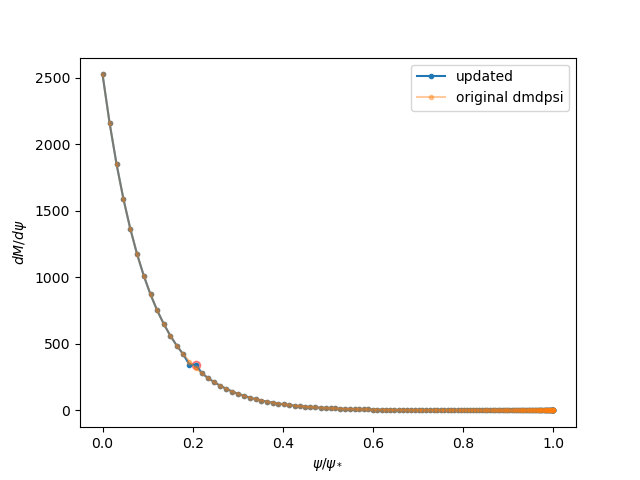

In [8]:
dmdpsi_updated = np.copy(dmdpsi_ref)

dmdpsi_updated[index - 1] -= delta_m/(psi_levels[index] - psi_levels[index-1])
dmdpsi_updated[index] += delta_m/(psi_levels[index+1] - psi_levels[index])

fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,dmdpsi_updated,'.-',label="updated")
ax.plot(psi_levels*psi_0/psi_star,dmdpsi_ref,'.-',alpha=0.4,label="original dmdpsi")
ax.scatter(psi_levels[index]*psi_0/psi_star,dmdpsi_updated[index],alpha=0.4,c='r')
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$dM/d\psi$")
plt.show()


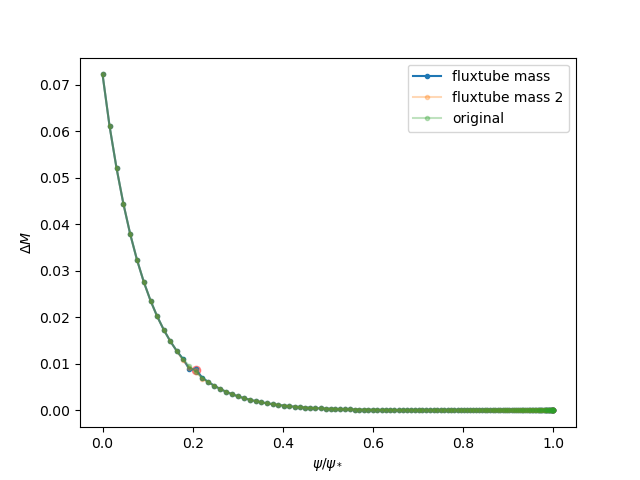

In [9]:
m_psi_calc_updated = np.array([simpson(dmdpsi_updated[:i+1],psi_levels[:i+1]) for i in range(len(dmdpsi_updated))])

fluxtube_mass_updated_2 = m_psi_calc_updated[1:] - m_psi_calc_updated[:-1]
fluxtube_mass_updated_2 = np.append(fluxtube_mass_updated_2,0)

fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass_updated,'.-',label="fluxtube mass")
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass_updated_2,'.-',label="fluxtube mass 2",alpha = 0.3)
ax.scatter(psi_levels[index]*psi_0/psi_star,fluxtube_mass_updated_2[index],alpha=0.4,c='r')
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass,'.-',alpha=0.3, label="original")
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$\Delta M$")
plt.show()

So you can see the effect of integration results in the masses not being equal! How to get around this?? Figure that out next time.

It's "next time"! Here's what I think - we have a deficit of mass in the left-hand fluxtube (i=13), at i=15, and the i=16 fluxtube, whilst we have an excess at the i=14 fluxtube. Calculate how much, and adjust dmdpsi.

In [10]:
difference = fluxtube_mass_updated - fluxtube_mass_updated_2
delta_m_delta_psi_3 = difference[:-1]/(psi_levels[1:] - psi_levels[:-1])
delta_m_delta_psi_3 = np.append(delta_m_delta_psi_3,0)
dmdpsi_updated_3 = dmdpsi_updated + delta_m_delta_psi_3
m_psi_calc_updated_3 = np.array([simpson(dmdpsi_updated_3[:i+1],psi_levels[:i+1]) for i in range(len(dmdpsi_updated_3))])
fluxtube_mass_updated_3 = m_psi_calc_updated_3[1:] - m_psi_calc_updated_3[:-1]
fluxtube_mass_updated_3 = np.append(fluxtube_mass_updated_3,0)

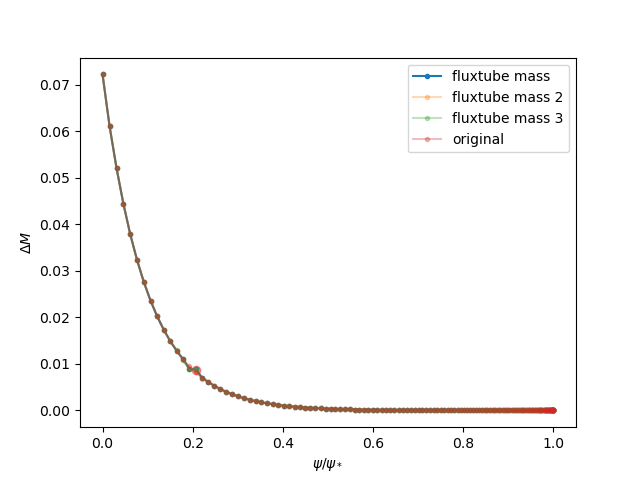

In [11]:
fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass_updated,'.-',label="fluxtube mass")
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass_updated_2,'.-',label="fluxtube mass 2",alpha = 0.3)
ax.scatter(psi_levels[index]*psi_0/psi_star,fluxtube_mass_updated_2[index],alpha=0.4,c='r')
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass_updated_3,'.-',label="fluxtube mass 3",alpha = 0.3)

ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass,'.-',alpha=0.3, label="original")
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$\Delta M$")
plt.show()

Check my understanding of the definition of dmdpsi, i.e. that the mass contained in a single fluxtube is equal to the integral of dmdpsi over dpsi. To do this, hand calculate $\int_{\psi}^{\psi + d\psi} dM/d\psi d\psi$, and compare to the numerical value of $M(\psi)$. Pick, for example, the fifth fluxtube:

In [12]:
j = 5
dmdpsi_j = dmdpsi_ref[j]
psi_j_1 = psi_levels[j+1]
psi_j_0 = psi_levels[j]

I think the solution to this is to avoid creating cusps in the mass-flux-distribution - i.e. ensure the distribution continues to be smooth. This would be achieved by using splines that preserve the gradient at their endpoints, as well as the integrated area underneath (this is the challenge).

In [13]:
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator
x = np.array([1., 2., 3., 4., 4.5, 5., 6., 7., 8])
y = x**2
y[4] += 101

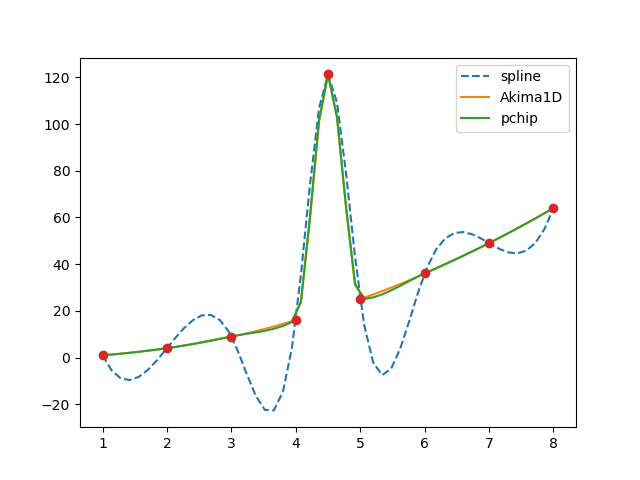

In [14]:
xx = np.linspace(1, 8, 51)
fig,ax = plt.subplots()
ax.plot(xx, CubicSpline(x, y)(xx), '--', label='spline')
ax.plot(xx, Akima1DInterpolator(x, y)(xx), '-', label='Akima1D')
ax.plot(xx, PchipInterpolator(x, y)(xx), '-', label='pchip')
ax.plot(x, y, 'o')
ax.legend()
plt.show()

Try fitting the adjusted dmdpsi with the Akima1D and pchip interpolators

In [15]:
akima1D_fit = Akima1DInterpolator(psi_levels*psi_0/psi_star,dmdpsi_updated)(psi_levels*psi_0/psi_star)
pchip_fit = PchipInterpolator(psi_levels*psi_0/psi_star,dmdpsi_updated)(psi_levels*psi_0/psi_star)
from scipy.interpolate import make_interp_spline
bspl_fit = make_interp_spline(psi_levels*psi_0/psi_star,dmdpsi_updated, k=3)(psi_levels*psi_0/psi_star)

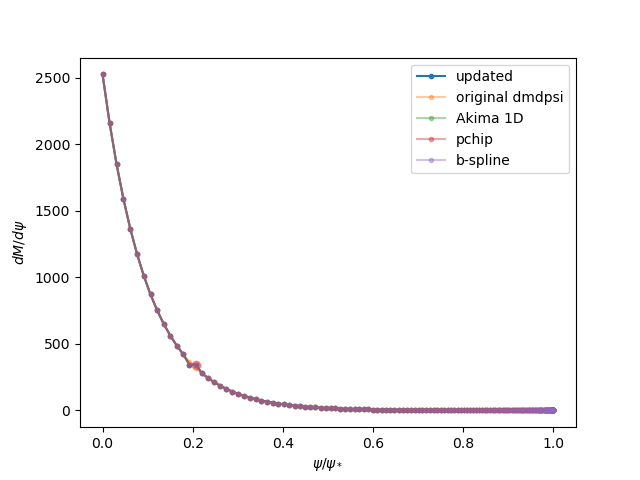

In [16]:
fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,dmdpsi_updated,'.-',label="updated")
ax.plot(psi_levels*psi_0/psi_star,dmdpsi_ref,'.-',alpha=0.4,label="original dmdpsi")
ax.scatter(psi_levels[index]*psi_0/psi_star,dmdpsi_updated[index],alpha=0.4,c='r')
ax.plot(psi_levels*psi_0/psi_star,akima1D_fit,'.-',alpha=0.4,label="Akima 1D")
ax.plot(psi_levels*psi_0/psi_star,pchip_fit,'.-',alpha=0.4,label="pchip")
ax.plot(psi_levels*psi_0/psi_star,bspl_fit,'.-',alpha=0.4,label="b-spline")
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$dM/d\psi$")
plt.show()

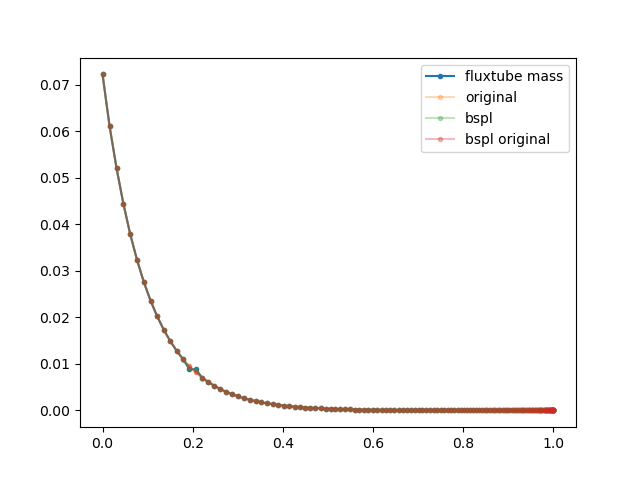

In [17]:
# integrate each spline

m_psi_bspl = np.array([simpson(bspl_fit[:i+1],psi_levels[:i+1]) for i in range(len(bspl_fit))])
fluxtube_mass_bspl = m_psi_bspl[1:] - m_psi_bspl[:-1]
fluxtube_mass_bspl = np.append(fluxtube_mass_bspl,0)

# fit original
bspl_m_psi_original = make_interp_spline(psi_levels*psi_0/psi_star,fluxtube_mass, k=3)(psi_levels*psi_0/psi_star)

fig,ax = plt.subplots()
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass_updated,'.-',label="fluxtube mass")
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass,'.-',alpha=0.3, label="original")
ax.plot(psi_levels*psi_0/psi_star,fluxtube_mass_bspl,'.-',alpha=0.3, label="bspl")
ax.plot(psi_levels*psi_0/psi_star,bspl_m_psi_original,'.-',alpha=0.3, label="bspl original")
ax.legend()
plt.show()

what about fitting M(psi) with a spline, then differentiating for dmdpsi, then integrating again to check?

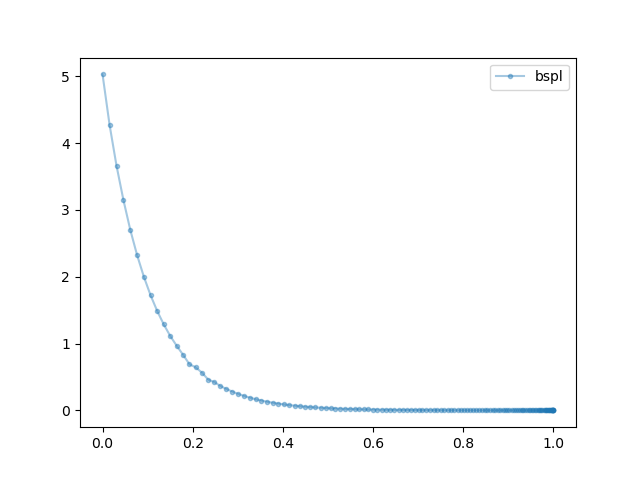

In [18]:
bspl_mpsi_fit = make_interp_spline(psi_levels*psi_0/psi_star,m_psi_calc_updated, k=3)

der = bspl_mpsi_fit.derivative()(psi_levels*psi_0/psi_star)

fig,ax = plt.subplots()
# ax.plot(psi_levels*psi_0/psi_star,dmdpsi_updated,'.-',label="updated")
ax.plot(psi_levels*psi_0/psi_star,der,'.-',label="bspl",alpha=0.4)
ax.legend()
plt.show()

I think what I need to do is continue with the method of picking a gradient for the unstable points, but add the smoothing to the boundaries of the unstable regions. Mass conservation will need to be upheld, which will be the challenge. Just start by forgetting about mass conservation - instead just get the spline transition working. To begin, create an unstable region, and set dmdpsi equal, then generate a spline connecting the region to the dmdpsi curve 2 flux surfaces away from it. Then place the intervening flux surfaces on this spline.

Adjusted region:
M_0 = 0.14797625
M_f = 0.14320031

Total:
M_0 = 0.50000209
M_f = 0.49527974
pct = 0.94446782%


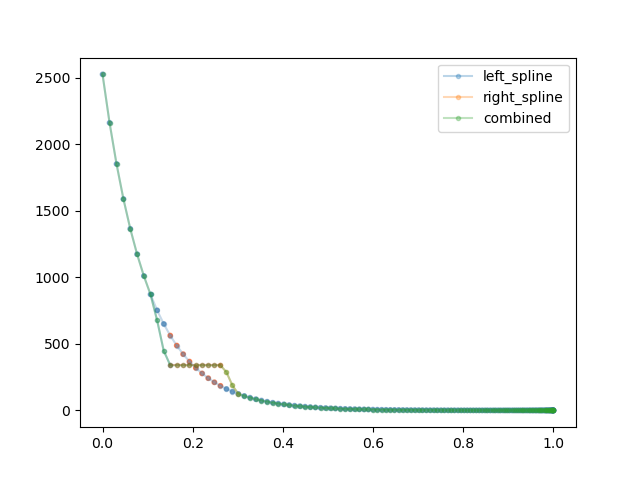

In [19]:
plt.close()
# create unstable region
start_index = 10
end_index = 18
color_array = np.zeros_like(psi_levels)
color_array[start_index:end_index+1] = 1

unstable_mass = simpson(dmdpsi_ref[start_index:end_index+1],psi_levels[start_index:end_index+1])
y0 = unstable_mass/(psi_levels[end_index] - psi_levels[start_index])
psi_scaled = psi_levels*psi_0/psi_star

# create splines
ghost_cells = 4
left_spline_start_index = start_index - ghost_cells + 1
right_spline_end_index = end_index + ghost_cells - 1

# calculate gradients at each side
dmdpsi_gradient = np.gradient(dmdpsi_ref,psi_scaled)
left_gradient = dmdpsi_gradient[left_spline_start_index]
right_gradient = dmdpsi_gradient[right_spline_end_index]

left_spline = CubicSpline(np.array([psi_scaled[left_spline_start_index],psi_scaled[start_index]]), np.array([dmdpsi_ref[left_spline_start_index],y0]),bc_type=((1,left_gradient),(1,0.0)))
left_spline_x_vals = np.linspace(psi_scaled[left_spline_start_index],psi_scaled[start_index],int(ghost_cells))

right_spline = CubicSpline(np.array([psi_scaled[end_index],psi_scaled[right_spline_end_index]]), np.array([y0,dmdpsi_ref[right_spline_end_index]]),bc_type=((1,0.),(1,right_gradient)))
right_spline_x_vals = np.linspace(psi_scaled[end_index],psi_scaled[right_spline_end_index],int(ghost_cells))

test_updated_dmdpsi = np.copy(dmdpsi_ref)
test_updated_dmdpsi[left_spline_start_index:start_index+1] = left_spline(left_spline_x_vals)
test_updated_dmdpsi[end_index:right_spline_end_index+1] = right_spline(right_spline_x_vals)
test_updated_dmdpsi[start_index:end_index] = y0

# calculate area
original_mass = simpson(dmdpsi_ref[left_spline_start_index:right_spline_end_index+1],psi_levels[left_spline_start_index:right_spline_end_index+1])
test_mass = simpson(test_updated_dmdpsi[left_spline_start_index:right_spline_end_index+1],psi_levels[left_spline_start_index:right_spline_end_index+1])

total_original_mass = simpson(dmdpsi_ref,psi_levels)
total_test_mass = simpson(test_updated_dmdpsi,psi_levels)
print("Adjusted region:")
print(f"M_0 = {original_mass:0.8f}")
print(f"M_f = {test_mass:0.8f}")
print("\nTotal:")
print(f"M_0 = {total_original_mass:0.8f}")
print(f"M_f = {total_test_mass:0.8f}")
print(f"pct = {(total_original_mass - total_test_mass)/total_original_mass*100:0.8f}%")
fig,ax = plt.subplots()
ax.plot(psi_scaled,dmdpsi_ref,'.-',c='steelblue',alpha=0.3)
ax.plot(left_spline_x_vals,left_spline(left_spline_x_vals),'.-',alpha = 0.3, label="left_spline")
ax.plot(right_spline_x_vals,right_spline(right_spline_x_vals),'.-',alpha = 0.3, label="right_spline")
ax.plot(psi_scaled[start_index:end_index+1],np.ones(end_index+1 - start_index)*y0,'.-',alpha=0.3,c='r')
ax.scatter(psi_scaled, dmdpsi_ref,c=np.where(color_array==1,'orangered','steelblue'),s=10,alpha=0.6)
ax.plot(psi_scaled,test_updated_dmdpsi,'.-',alpha=0.3,label='combined')
ax.legend()
plt.show()

We instead choose a parameterised functional form for the region - try a generalised logistic function:
\begin{equation}
Y(t) = A + \frac{K - A}{(C + Q e^{-Bt})^{1/\nu}}
\end{equation}

Here:
- $A$: left horizontal asymptote
- $K$: right horizontal asymptote when $C=1$
- $B$: growth rate
- $\nu>0$: changes where growth occurs (near which asymptote)
- $Q$: scales $Y(0)$
- $C$: typically 1

For example:

\begin{equation}
Y(t) = \frac{1}{1 + e^{-t}}
\end{equation}

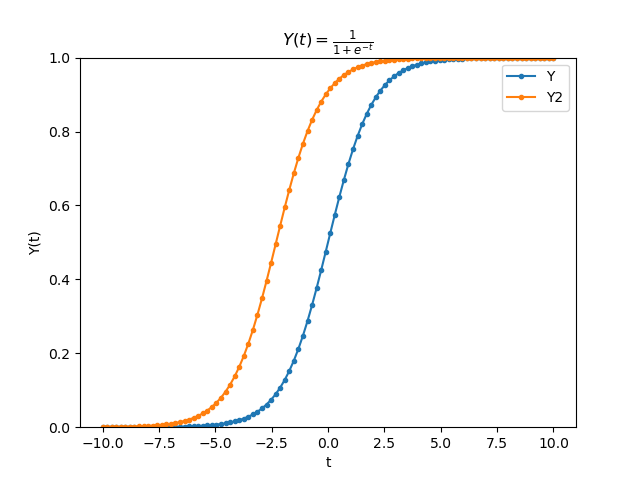

In [20]:
A = 0
K = 1
B = 1
C = 1
Q = 1
nu = 1

A2 = 0
K2 = 1
B2 = 1
C2 = 1
Q2 = 0.1
nu2 = 1

t = np.linspace(-10,10,100)
Y = A + (K - A)/(C + Q*np.exp(-B*t))**(1./nu)
Y2 = A2 + (K2 - A2)/(C2 + Q2*np.exp(-B2*t))**(1./nu2)

fig,ax = plt.subplots()
ax.plot(t,Y,'.-',label='Y')
ax.plot(t,Y2,'.-',label="Y2")
ax.set(xlabel="t",ylabel="Y(t)",title = r"$Y(t) = \frac{1}{1+e^{-t}}$",ylim=[0,1])
ax.legend()
plt.show()

To reverse, set $A = 1, K = 0$:

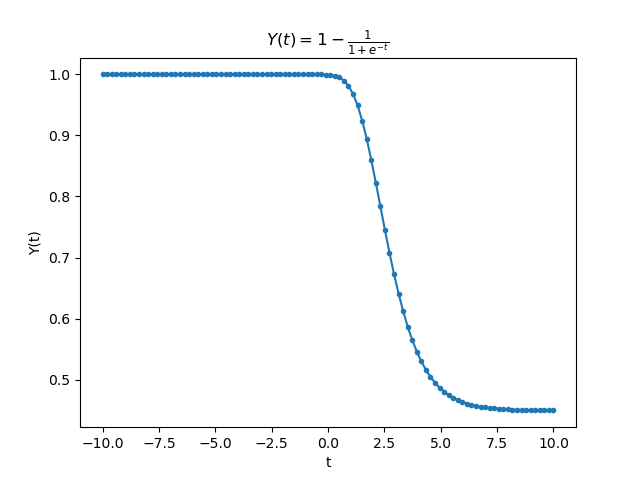

In [21]:
B = 1
K = np.exp(-4/5)
A = 1
nu = 0.1
Y = A + (K - A)/(C + Q*np.exp(-B*t))**(1./nu)


fig,ax = plt.subplots()
ax.plot(t,Y,'.-')
ax.set(xlabel="t",ylabel="Y(t)",title = r"$Y(t) = 1 -\frac{1}{1+e^{-t}}$")

plt.show()

To do: 
- check integral
- think how to match gradients: to do this, multiply whole function by constant gradient

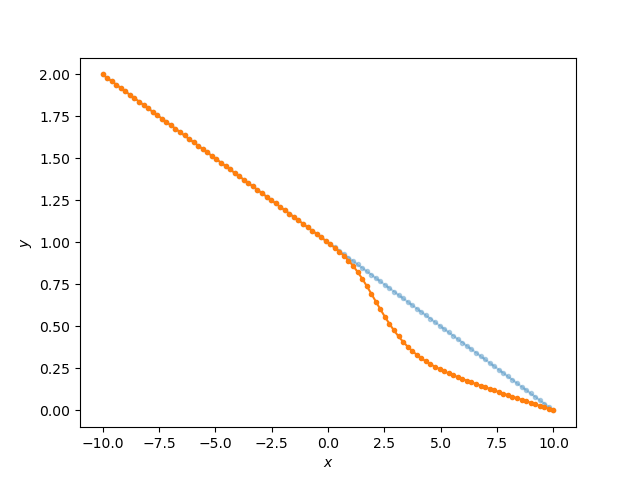

In [22]:
#gradient
y = 1 - t/10
scaled_Y = y * Y
fig,ax = plt.subplots()
ax.plot(t,y,'.-',alpha=0.3)
ax.plot(t,scaled_Y,'.-')
ax.set(xlabel=r"$x$",ylabel=r"$y$")
plt.show()

Try multiplying by $e^{-t}$ instead:

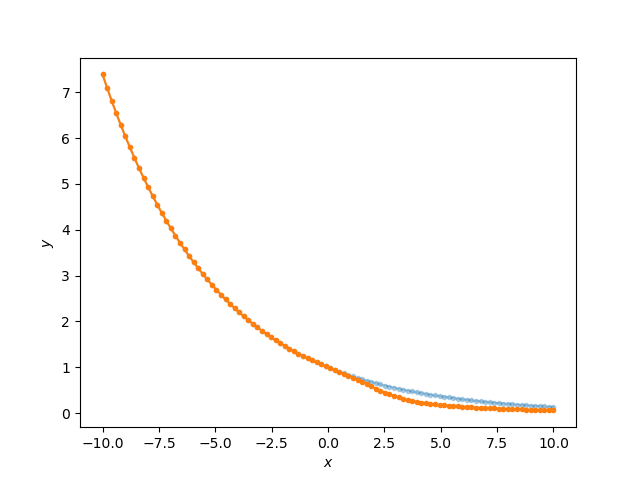

In [23]:
yy = np.exp(-t/5)
YY_scaled = yy * Y

fig,ax = plt.subplots()
ax.plot(t,yy,'.-',alpha=0.3)
ax.plot(t,YY_scaled,'.-')
ax.set(xlabel=r"$x$",ylabel=r"$y$")
plt.show()

Rather than sigmoid, what about a trigonometric function like $\sin(\frac{2\pi x}{L})$? We need the s-curve to reduce dmdpsi up to a point, then increase it. The sigmoid can't do this, as it simply switches between two different values smoothly.

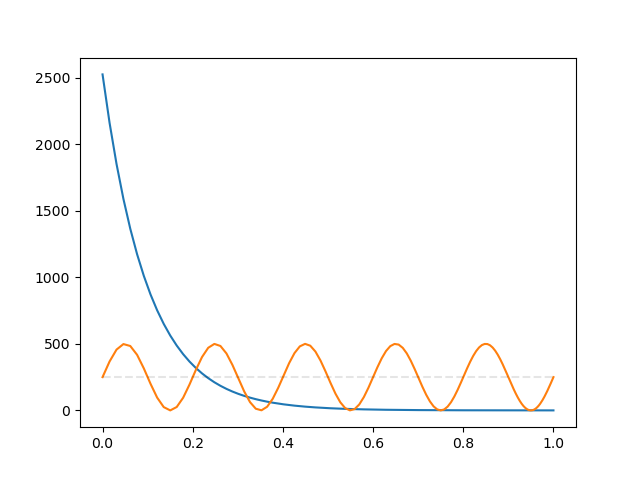

In [24]:
# define sine function
L = 0.2
phi_0 = 0.2
y_sin = 250*np.sin(2*np.pi*(psi_scaled + phi_0)/L)+250
# plot dmdpsi_ref again
fig,ax = plt.subplots()
ax.plot(psi_scaled,dmdpsi_ref)
ax.plot(psi_scaled,y_sin)
ax.plot(psi_scaled,250.0*np.ones_like(psi_scaled),'--k',alpha=0.1)
plt.show()
plt.close()


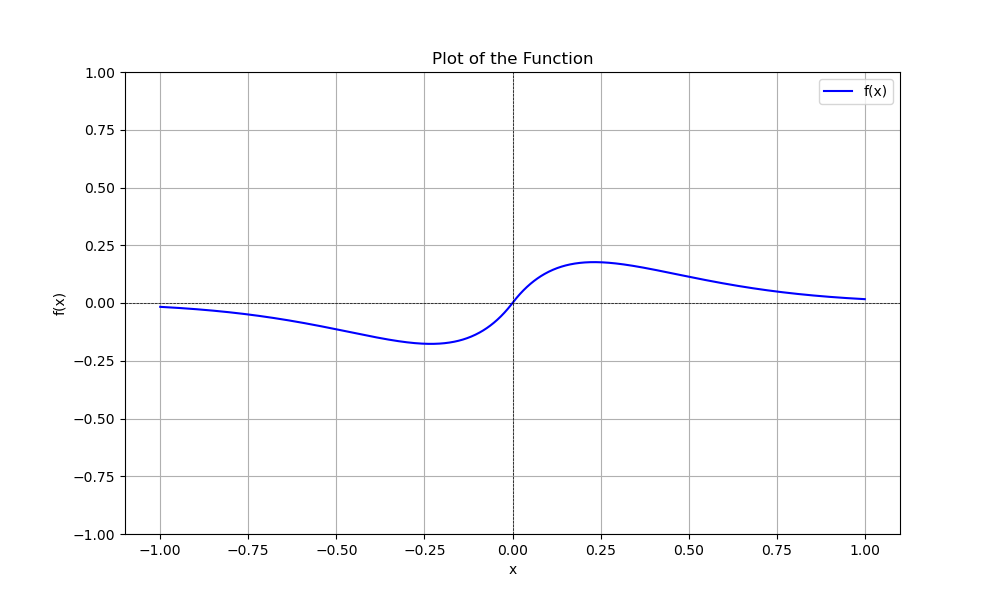

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(x):
    if x < 0:
        return np.exp(4*x) * np.sin(2*x)
    elif x > 0:
        return np.exp(-4*x) * np.sin(2*x)
    else:
        return 0

# Generate x values
x_values = np.linspace(-1, 1, 1000)
y_values = np.array([f(x) for x in x_values])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x)', color='blue')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.title('Plot of the Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-1, 1)
plt.grid()
plt.legend()
plt.show()


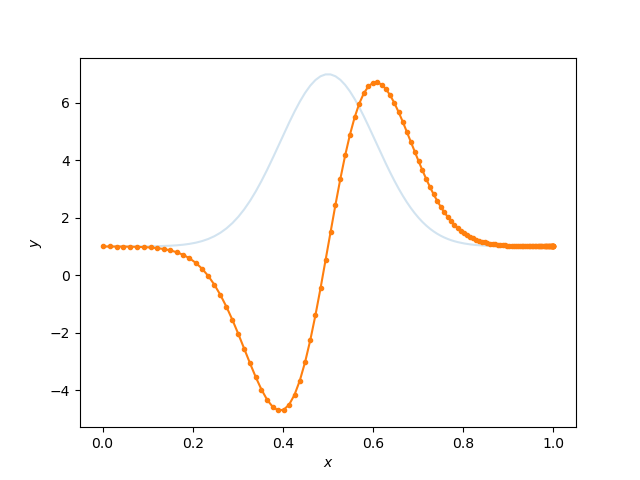

In [26]:
# Try a Gaussian
mu_0 = 0.5
sigma = 0.15
y_normal = 1+ np.exp(-(psi_scaled - mu_0)**2/(sigma**2))
deriv =  1+2*(psi_scaled - mu_0)/sigma**2*np.exp(-(psi_scaled - mu_0)**2/(sigma**2))

fig,ax = plt.subplots()
ax.plot(psi_scaled,(y_normal-1)*6 + 1, alpha = 0.2)
ax.plot(psi_scaled,deriv, '.-')
ax.set(xlabel=r"$x$",ylabel=r"$y$")
plt.show()

area_ref = 252.42780544, area_mod = 244.37042190
area_wavelet = 1.00000000


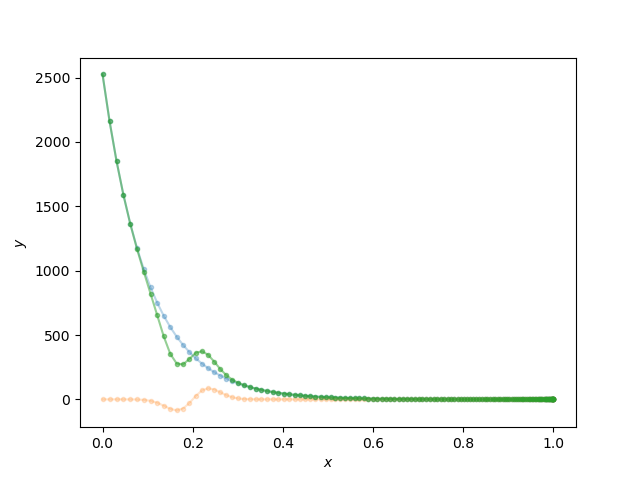

In [27]:
# Now we want to modulate the exponential with the function. Resize the wavelet to localise it on the dmdpsi plot:

mu_0 = 0.2
sigma = 0.05
amplitude = 0.05

y_wavelet = 1 + amplitude*(psi_scaled - mu_0)/sigma**2 * np.exp(-(psi_scaled - mu_0)**2/sigma**2)

# calculate integral and compare

y_modified = y_wavelet*dmdpsi_ref

area_ref = simpson(dmdpsi_ref,x=psi_scaled)
area_modified = simpson(y_modified,x=psi_scaled)
area_wavelet = simpson(y_wavelet,x=psi_scaled)


print(f"area_ref = {area_ref:0.8f}, area_mod = {area_modified:0.8f}")
print(f"area_wavelet = {area_wavelet:0.8f}")

fig,ax = plt.subplots()
ax.plot(psi_scaled,dmdpsi_ref,'.-', alpha = 0.3)
ax.plot(psi_scaled,(y_wavelet-1)*200+1, '.-', alpha = 0.2)
ax.plot(psi_scaled,y_modified, '.-', alpha = 0.5)
ax.set(xlabel=r"$x$",ylabel=r"$y$")
plt.show()


try a skew-normal distribution:
\begin{equation}
f(x,\alpha,\mu,\sigma) = \frac{1}{\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}\left[ 1 + \mathrm{erf}\left(\frac{\alpha(x-\mu)}{\sqrt{2\sigma^2}}\right)\right]
\end{equation}

area = 0.000000000


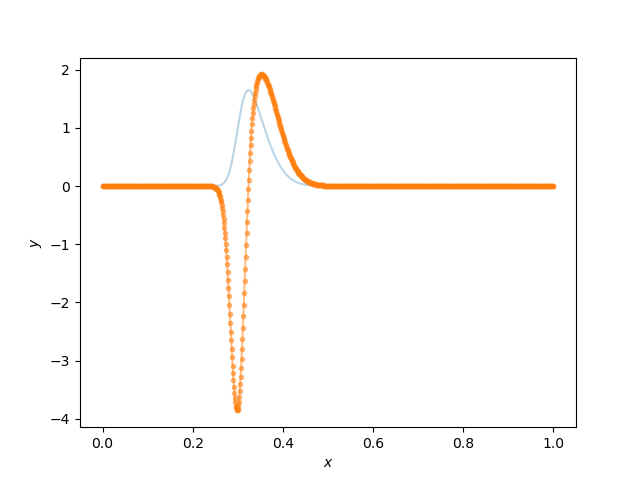

In [28]:
from scipy.special import erf
alpha = 3
alpha_norm = 1
sigma = 0.05
mu0 = 0.3
x = np.linspace(0,1,1000)
def Norm(x,mu,sigma,alpha_norm):
    return np.exp(-alpha_norm**2*(x - mu)**2/2/sigma**2)

def Phi(x,mu,sigma,alpha):
    return 0.5*(1 + erf(alpha*(x - mu)/sigma/np.sqrt(2)))

def func_deriv_skew_normal(x,mu,sigma,alpha):
    return -Norm(x,mu0,sigma,1)/sigma**2*(np.sqrt(2/np.pi)*alpha*sigma*Norm(x,mu0,sigma,alpha) - (x - mu0)*2*Phi(x,mu0,sigma,alpha))

skew_normal = 2*Norm(x,mu0,sigma,alpha_norm)*Phi(x,mu0,sigma,alpha)
# deriv_skew_normal = Norm(psi_scaled,mu0,sigma,1)/sigma**2*(np.sqrt(2/np.pi)*alpha*sigma*Norm(psi_scaled,mu0,sigma,alpha) - (psi_scaled - mu0)*2*Phi(psi_scaled,mu0,sigma,alpha))
deriv_skew_normal = func_deriv_skew_normal(x,mu0,sigma,alpha)
area_skew_normal = simpson(deriv_skew_normal,x=x)
print(f"area = {area_skew_normal:0.9f}")


fig,ax = plt.subplots()
ax.plot(x,skew_normal,alpha = 0.3)
ax.plot(x,0.08*deriv_skew_normal,'.-',alpha = 0.5)
ax.set(xlabel=r"$x$",ylabel=r"$y$")
plt.show()

area_ref = 252.42780544, area_mod = 249.56880490


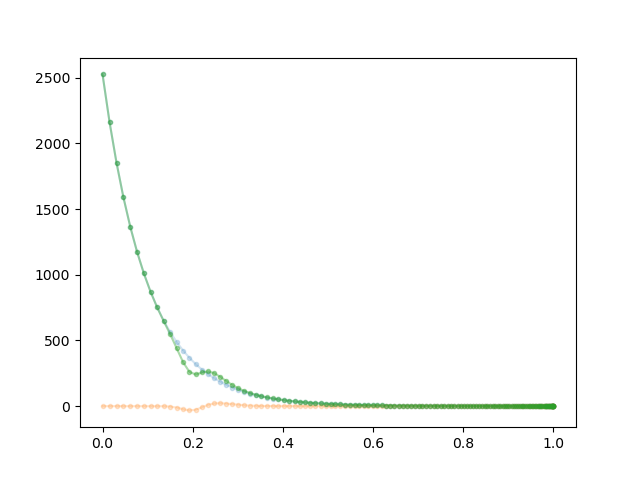

In [29]:
# now multiply by dmdpsi
a0 = 0.009
mu0 = 0.2
sigma = 0.05
alpha = 2
skew_mod_dmdpsi = dmdpsi_ref * (1 + a0 * func_deriv_skew_normal(psi_scaled,mu0,sigma,alpha))

# calculate areas
area_skew_mod_dmdpsi = simpson(skew_mod_dmdpsi,x=psi_scaled)

print(f"area_ref = {area_ref:0.8f}, area_mod = {area_skew_mod_dmdpsi:0.8f}")
fig,ax = plt.subplots()
ax.plot(psi_scaled,dmdpsi_ref, '.-',alpha = 0.2)
ax.plot(psi_scaled,func_deriv_skew_normal(psi_scaled,mu0,sigma,alpha), '.-',alpha = 0.2)
ax.plot(psi_scaled,skew_mod_dmdpsi, '.-', alpha = 0.4)
plt.show()

/var/folders/72/5_kw1gh53nn015l6nm1_9csw0000gn/T/ipykernel_24169/2687402377.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots()


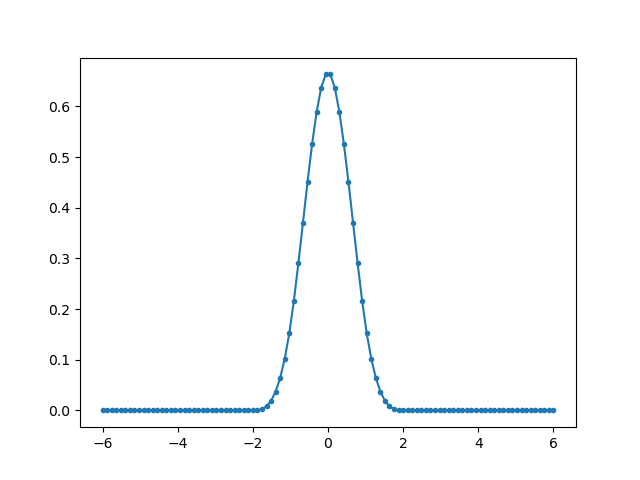

In [30]:
# try third order B-spline

def b_spline(x):
    if(np.abs(x) < 1):
        b_spl = (4 - 6*np.abs(x)**2 + 3*np.abs(x)**3)/6
    elif(np.abs(x) < 2):
        b_spl = (2 - np.abs(x))**3 / 6
    else:
        b_spl = 0
    return b_spl

x = np.linspace(-6,6,100)
y = [b_spline(x[i]) for i in range(len(x))]

fig,ax = plt.subplots()
ax.plot(x,y,'.-')
plt.show()

Simplified version, the PRHL function:
\begin{equation}
f(x,\alpha,\mu,\lambda) = \frac{\alpha \lambda e^{-\lambda(x-\mu)}}{(1 + e^{-\lambda(x-\mu)})^{\alpha+1}}
\end{equation}

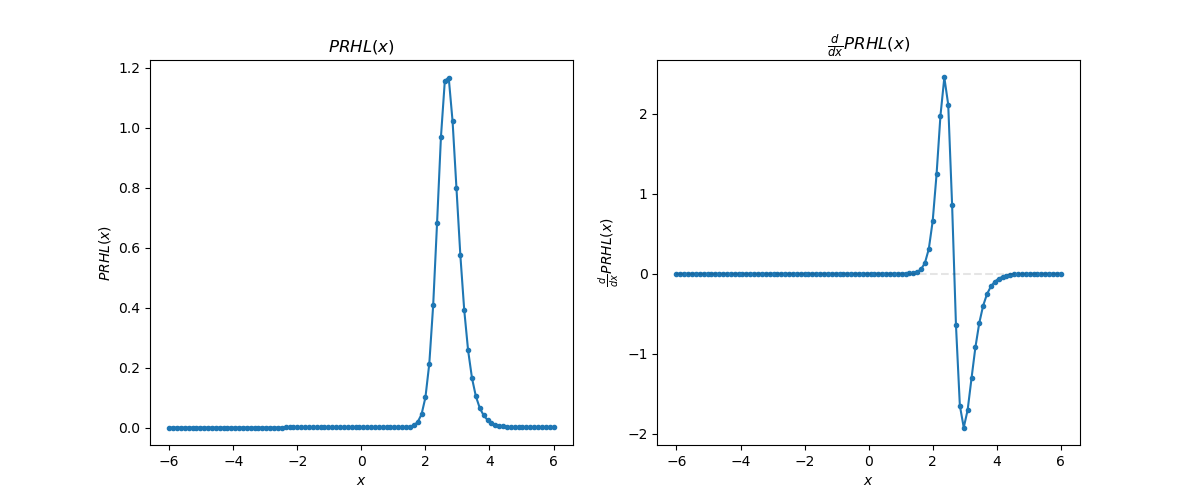

In [31]:
# Try proportional reversed hazard logistic (PRHL) function  (https://home.iitk.ac.in/~kundu/paper152.pdf)
def prhl(x, alpha, mu, lmda):
    return alpha*lmda*np.exp(-lmda*(x-mu))/(1 + np.exp(-lmda*(x-mu)))**(alpha+1)

# derivative:
def d_prhl(x,alpha,mu,ll):
    return -alpha*ll**2*(np.exp(ll*(x - mu)) - alpha)/(1 + np.exp(-ll*(x-mu)))**alpha/(1 + np.exp(ll*(x - mu)))**2

alpha = 2
mu = 2.5
ll = 4
prhl_test = prhl(x,alpha,mu,ll)
test_d_prhl = d_prhl(x,alpha,mu,ll)

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.plot(x,prhl_test,'.-')
ax2.plot(x,test_d_prhl,'.-')
ax2.plot(x,np.zeros_like(x),'--k',alpha = 0.1)
ax.set(title=r'$PRHL(x)$',xlabel='$x$',ylabel=r'$PRHL(x)$')
ax2.set(title=r'$\frac{d}{dx}PRHL(x)$',xlabel='$x$',ylabel=r'$\frac{d}{dx}PRHL(x)$')
plt.show()

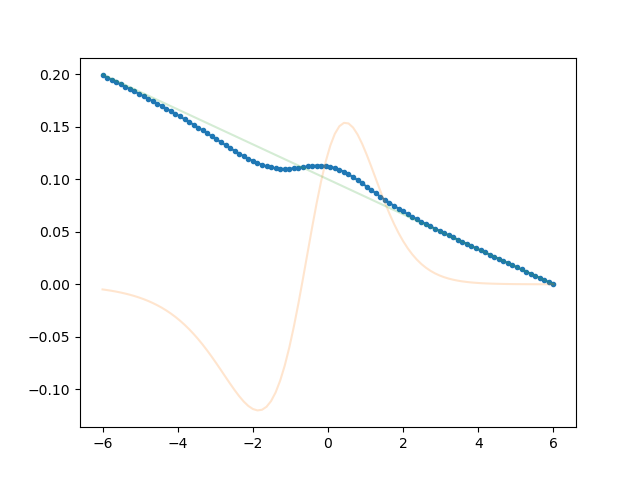

In [32]:
# now multiply by a straight line
m = -0.2/12
Y = m*x + 0.1
alpha = 2
mu = 0
ll = -1
prhl_test = prhl(x,alpha,mu,ll)
test_d_prhl = d_prhl(x,alpha,mu,ll)

mod_d_prhl = Y * (1+test_d_prhl)

fig,ax = plt.subplots()
ax.plot(x,mod_d_prhl,'.-')
ax.plot(x,test_d_prhl,alpha = 0.2)
ax.plot(x,Y,alpha =0.2)
plt.show()

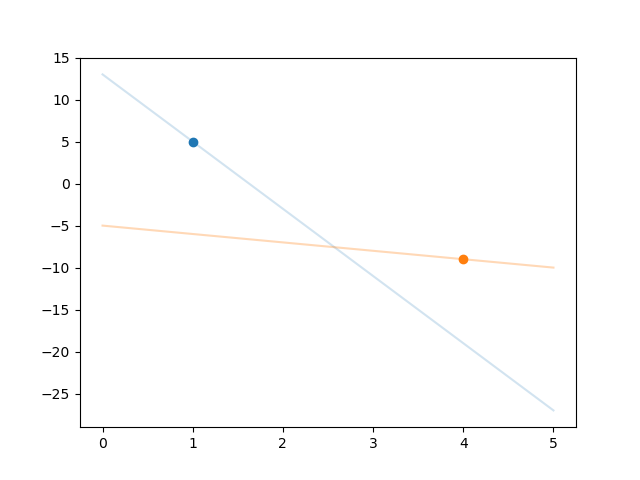

In [33]:
x = np.linspace(0,5,100)
m0 = -8
m1 = -1

x0 = 1
y0 = 5
x1 = 4
y1 = -9

Y0 = m0*(x - x0) + y0
Y1 = m1*(x - x1) + y1
t= np.linspace(0,1,100)
YY = (1 - t)*Y0 + t*Y1
xx = (1 - t)*x0 + t*x1
fig,ax = plt.subplots()
ax.plot(x,Y0,alpha = 0.2)
ax.plot(x,Y1,alpha = 0.3)
ax.scatter(x0,y0)
ax.scatter(x1,y1)
plt.show()

-884.8957876917925 0.0615234375 -15945.923172287832


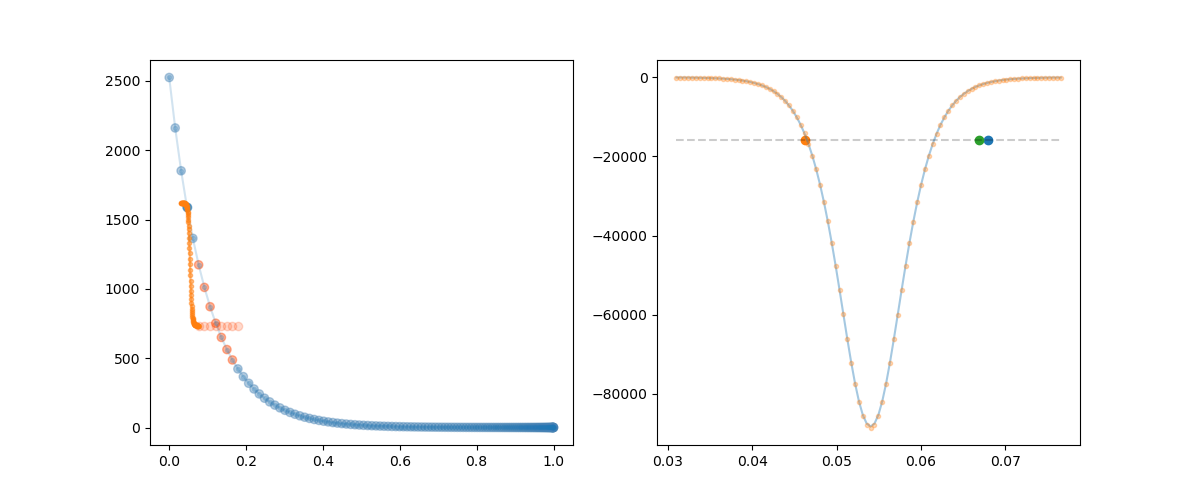

In [34]:
#Try test algorithm manually

start_index = 5
end_index = 12
color_array = np.zeros_like(psi_scaled)
color_array[start_index:end_index] = 1

# step 1
unstable_mass = simpson(dmdpsi_ref[start_index:end_index+1],x=psi_levels[start_index:end_index+1])
flats = unstable_mass / (psi_levels[end_index] - psi_levels[start_index]) * np.ones_like(psi_scaled[start_index:end_index+1])

# step 2: S1 construction
# choose x 2 points prior  to start of unstable region
s1_x0_index = start_index - 2
s1_x0 = psi_levels[s1_x0_index]

# find gradient at this point
s1_k0 = np.gradient(dmdpsi_ref,psi_scaled)[s1_x0_index]

t1 = np.linspace(psi_scaled[s1_x0_index-1],psi_scaled[start_index],100)
t01 = psi_scaled[start_index - 1]
K1 = flats[0]
A1 = 1.02*dmdpsi_ref[s1_x0_index]
C1= 1
Q1 = 0.05
B1 = 400
print(K1- A1,t01,s1_k0)
y1 = A1 + (K1 - A1)/(C1 + Q1*np.exp(-B1*(t1 - t01)))

x_gradient_1 = (np.log((-np.sqrt(B1)*Q1*np.sqrt(A1 - K1)*np.sqrt(A1*B1 -B1*s1_k0 + 4*C1*s1_k0) - A1*B1*Q1 + B1*s1_k0*Q1 - 2*C1*s1_k0*Q1)/(2*C1**2*s1_k0)) + B1*t01)/B1
x_gradient_2 = (np.log(-s1_k0*Q1/(B1*(A1-K1))) + B1*t01)/B1
x_gradient_3 = (np.log((np.sqrt(B1)*Q1*np.sqrt(A1 - K1)*np.sqrt(A1*B1 -B1*s1_k0 + 4*C1*s1_k0) - A1*B1*Q1 + B1*s1_k0*Q1 - 2*C1*s1_k0*Q1)/(2*C1**2*s1_k0)) + B1*t01)/B1


fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.plot(psi_scaled,dmdpsi_ref,'.-',alpha = 0.2)
ax.scatter(psi_scaled,dmdpsi_ref,c=np.where(color_array==1,'orangered','steelblue'),alpha = 0.4)
ax.scatter(psi_scaled[start_index:end_index+1],flats,c='orangered',alpha = 0.2)
ax.scatter(psi_scaled[s1_x0_index],dmdpsi_ref[s1_x0_index],alpha = 0.5)
ax.plot(t1,y1,'.-',alpha = 0.5)
# ax.set(xlim=[0.04,0.058],ylim = [1500,1680])
ax2.plot(t1,np.gradient(y1,t1),'-',alpha=0.4)
ax2.plot(t1,B1*Q1*(K1-A1)*np.exp(-B1*(t1-t01))/(C1 + Q1*np.exp(-B1*(t1-t01)))**2,'.',alpha = 0.3)
ax2.plot(t1,np.ones_like(t1)*s1_k0, '--k',alpha=0.2)
ax2.scatter(x_gradient_1,s1_k0)
ax2.scatter(x_gradient_2,s1_k0)
ax2.scatter(x_gradient_3,s1_k0)
plt.show()